 start plotting

 [Baseline 1] Skipped non-comparative data: Baseline 1 (Matrix Factorization) - Full Ranking
 [Baseline 1] Fair assessment data has been successfully retrieved: Baseline 1 (Matrix Factorization) - Fair Sampled
 [Baseline 2] Fair assessment data has been successfully retrieved: Baseline 2 (BERT Content-Based) - Fair Sampled
 [Hybrid Model] Fair assessment data has been successfully retrieved: Attention-Based Hybrid Model - Fair Sampled

 success! start plotting...


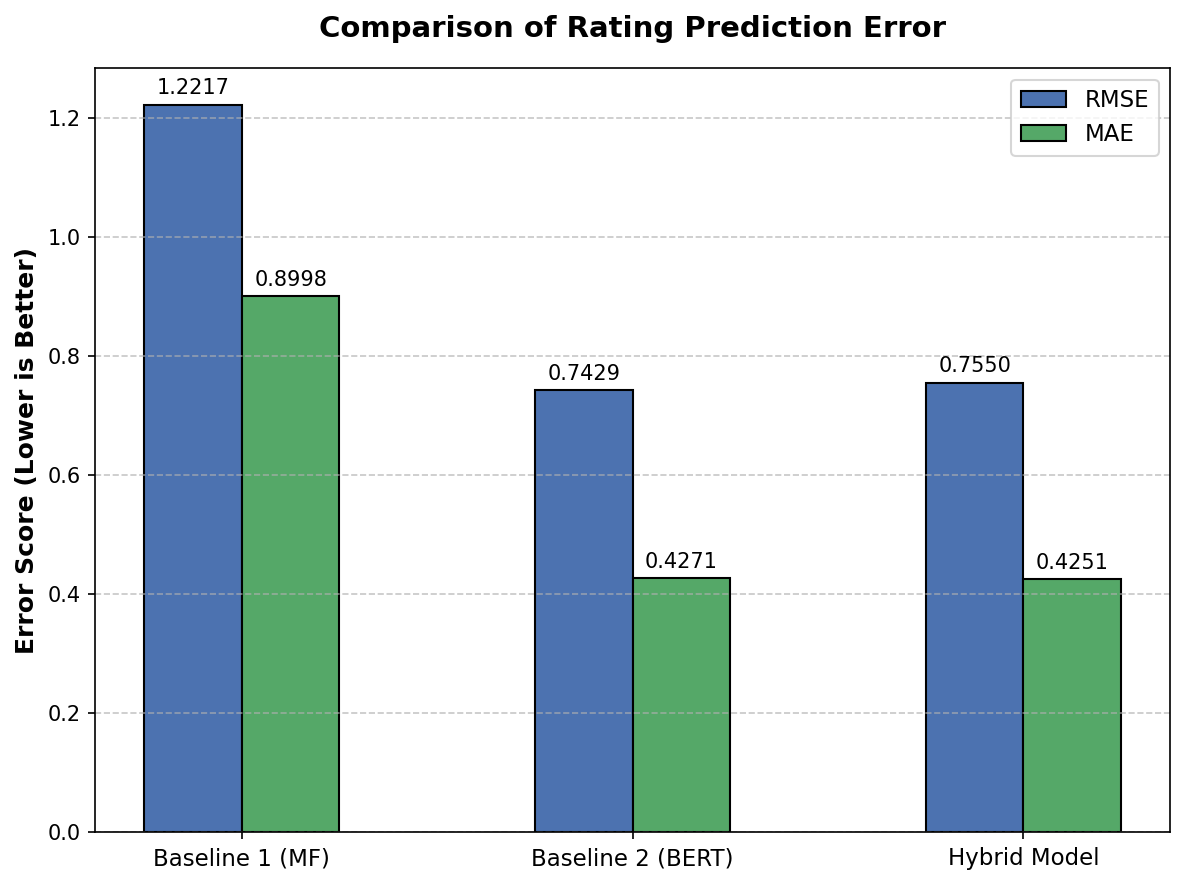

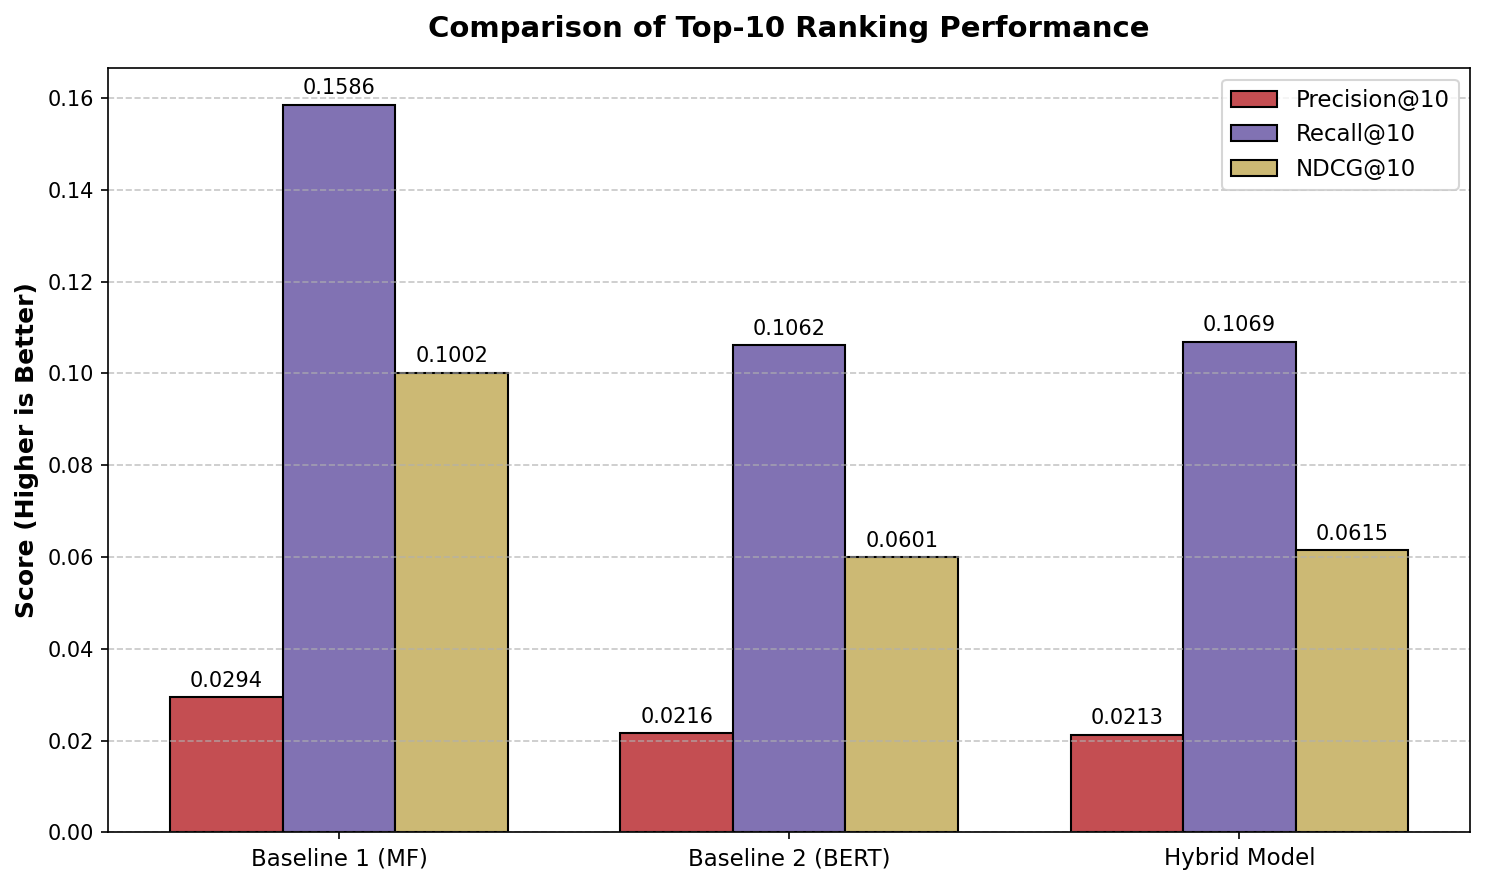


 success!saved!


In [ ]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Loading Module

def load_fair_sampled_data(file_path, label):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"can not found: {file_path}")

    with open(file_path, 'r', encoding='utf-8') as f:
        data_list = json.load(f)
        for entry in data_list:
            model_name = entry.get('model_name', entry.get('model name', 'Untitled Model'))

            # Differentiate between Full Ranking and Fair Sampled
            if 'Fair Sampled' in model_name:
                print(f" [{label}] Fair assessment data has been successfully retrieved: {model_name}")
                return entry
            else:
                print(f" [{label}] Skipped non-comparative data: {model_name}")

    raise ValueError(f" can not find record in {file_path}")

def extract_metrics_robust(entry, file_label):
    keys_rmse = ['RMSE', 'RMSE ', 'rmse']
    keys_mae = ['MAE', 'MAE ', 'mae']
    keys_p10 = ['Precision_10', 'Precision 10', 'precision 10']
    keys_r10 = ['Recall_10', 'Recall 10', 'recall 10']
    keys_n10 = ['NDCG_10', 'NDCG 10', 'ndcg 10']

    def get_val(possible_keys, metric_name):
        for k in possible_keys:
            if k in entry:
                return float(entry[k])
        raise KeyError(f" error: can not find {metric_name} in {file_label}!")

    return (
        get_val(keys_rmse, "RMSE"),
        get_val(keys_mae, "MAE"),
        get_val(keys_p10, "Precision@10"),
        get_val(keys_r10, "Recall@10"),
        get_val(keys_n10, "NDCG@10")
    )

print(" start plotting\n")

# 2. Read and Extract Data

path_b1 = '/content/first_experiment_results.json'
path_b2 = '/content/second_experiment_results.json'
path_hybrid = '/content/final_hybrid_results.json'

# Print filtering process
b1_data = load_fair_sampled_data(path_b1, "Baseline 1")
b2_data = load_fair_sampled_data(path_b2, "Baseline 2")
hybrid_data = load_fair_sampled_data(path_hybrid, "Hybrid Model")

b1_metrics = extract_metrics_robust(b1_data, "Baseline 1")
b2_metrics = extract_metrics_robust(b2_data, "Baseline 2")
hybrid_metrics = extract_metrics_robust(hybrid_data, "Hybrid Model")

# 3. Assemble Data and Plot

labels = ['Baseline 1 (MF)', 'Baseline 2 (BERT)', 'Hybrid Model']
rmse_scores = [b1_metrics[0], b2_metrics[0], hybrid_metrics[0]]
mae_scores =  [b1_metrics[1], b2_metrics[1], hybrid_metrics[1]]
precision_scores = [b1_metrics[2], b2_metrics[2], hybrid_metrics[2]]
recall_scores =    [b1_metrics[3], b2_metrics[3], hybrid_metrics[3]]
ndcg_scores =      [b1_metrics[4], b2_metrics[4], hybrid_metrics[4]]

print("\n success! start plotting...")

x = np.arange(len(labels))
width = 0.25

def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

# --- Figure 1: Error Plot ---
fig1, ax1 = plt.subplots(figsize=(8, 6), dpi=150)
rects1 = ax1.bar(x - width/2, rmse_scores, width, label='RMSE', color='#4C72B0', edgecolor='black')
rects2 = ax1.bar(x + width/2, mae_scores, width, label='MAE', color='#55A868', edgecolor='black')

ax1.set_ylabel('Error Score (Lower is Better)', fontsize=12, fontweight='bold')
ax1.set_title('Comparison of Rating Prediction Error', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

autolabel(rects1, ax1)
autolabel(rects2, ax1)
fig1.tight_layout()
plt.savefig('/content/rating_prediction_comparison.png')
plt.show()

# --- Figure 2: Ranking Plot ---
fig2, ax2 = plt.subplots(figsize=(10, 6), dpi=150)
rects3 = ax2.bar(x - width, precision_scores, width, label='Precision@10', color='#C44E52', edgecolor='black')
rects4 = ax2.bar(x, recall_scores, width, label='Recall@10', color='#8172B3', edgecolor='black')
rects5 = ax2.bar(x + width, ndcg_scores, width, label='NDCG@10', color='#CCB974', edgecolor='black')

ax2.set_ylabel('Score (Higher is Better)', fontsize=12, fontweight='bold')
ax2.set_title('Comparison of Top-10 Ranking Performance', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

autolabel(rects3, ax2)
autolabel(rects4, ax2)
autolabel(rects5, ax2)
fig2.tight_layout()
plt.savefig('/content/ranking_performance_comparison.png')
plt.show()

print("\n success!saved!")

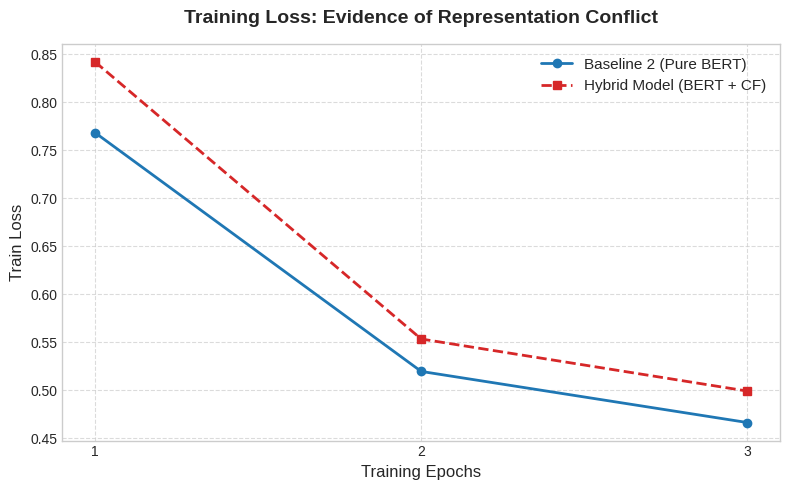

In [ ]:
import matplotlib.pyplot as plt

# ================= Data Preparation (Excluding Baseline 1) =================
# Baseline 2 (BERT) - 3 Epochs
epochs = [1, 2, 3]
b2_train_loss = [0.7684, 0.5195, 0.4662]

# Hybrid Model - 3 Epochs
hybrid_train_loss = [0.8422, 0.5533, 0.4990]

# ================= Plotting Settings =================
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 5))

# Plot two Loss curves
plt.plot(epochs, b2_train_loss, marker='o', linestyle='-', color='#1f77b4', linewidth=2, label='Baseline 2 (Pure BERT)')
plt.plot(epochs, hybrid_train_loss, marker='s', linestyle='--', color='#d62728', linewidth=2, label='Hybrid Model (BERT + CF)')

# Chart beautification and labels
plt.title('Training Loss: Evidence of Representation Conflict', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Train Loss', fontsize=12)
plt.xticks(epochs)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()